In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # important for SMOTE in pipeline

In [7]:
# bring in dataset
df=pd.read_csv(r'C:\Users\user\Desktop\breast-cancer-dataset.csv')

In [8]:
# top layer view
df.head()

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,1,2019,40,1,2,0,Right,0,Upper inner,0,Benign
1,2,2019,39,1,2,0,Left,0,Upper outer,0,Benign
2,3,2019,45,0,4,0,Left,0,Lower outer,0,Benign
3,4,2019,26,1,3,0,Left,0,Lower inner,1,Benign
4,5,2019,21,1,1,0,Right,0,Upper outer,1,Benign


In [9]:
# shape view
df.shape

(213, 11)

In [10]:
# general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S/N               213 non-null    int64 
 1   Year              213 non-null    object
 2   Age               213 non-null    int64 
 3   Menopause         213 non-null    int64 
 4   Tumor Size (cm)   213 non-null    object
 5   Inv-Nodes         213 non-null    object
 6   Breast            213 non-null    object
 7   Metastasis        213 non-null    object
 8   Breast Quadrant   213 non-null    object
 9   History           213 non-null    object
 10  Diagnosis Result  213 non-null    object
dtypes: int64(3), object(8)
memory usage: 18.4+ KB


In [11]:
# check for null values
df.isnull().sum()/len(df)

S/N                 0.0
Year                0.0
Age                 0.0
Menopause           0.0
Tumor Size (cm)     0.0
Inv-Nodes           0.0
Breast              0.0
Metastasis          0.0
Breast Quadrant     0.0
History             0.0
Diagnosis Result    0.0
dtype: float64

In [12]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# high cardinality check
df.nunique()

S/N                 213
Year                  3
Age                  58
Menopause             2
Tumor Size (cm)      13
Inv-Nodes             4
Breast                3
Metastasis            3
Breast Quadrant       6
History               3
Diagnosis Result      2
dtype: int64

In [14]:
# remove irrelevant and high cardinality columns
df.drop(columns=['S/N','Year'],inplace=True)
df.head()

,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,40,1,2,0,Right,0,Upper inner,0,Benign
1,39,1,2,0,Left,0,Upper outer,0,Benign
2,45,0,4,0,Left,0,Lower outer,0,Benign
3,26,1,3,0,Left,0,Lower inner,1,Benign
4,21,1,1,0,Right,0,Upper outer,1,Benign


In [15]:
# clean up defective columns
df['Tumor Size (cm)'] = df['Tumor Size (cm)'].replace('#',11)
df['Inv-Nodes'] = df['Inv-Nodes'].replace('#', 2)
df['Metastasis'] = df['Metastasis'].replace('#',2)
df['History'] = df['History'].replace('#',2)

In [16]:
# recast the data types
df['Tumor Size (cm)'] = df['Tumor Size (cm)'].astype(int)
df['Inv-Nodes'] = df['Inv-Nodes'].astype(int)
df['Metastasis'] = df['Metastasis'].astype(int)
df['History'] = df['History'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               213 non-null    int64 
 1   Menopause         213 non-null    int64 
 2   Tumor Size (cm)   213 non-null    int64 
 3   Inv-Nodes         213 non-null    int64 
 4   Breast            213 non-null    object
 5   Metastasis        213 non-null    int64 
 6   Breast Quadrant   213 non-null    object
 7   History           213 non-null    int64 
 8   Diagnosis Result  213 non-null    object
dtypes: int64(6), object(3)
memory usage: 15.1+ KB


In [17]:
# check for multicolinearity
mc = df.select_dtypes('number')
heat = mc.corr()
heat

,Age,Menopause,Tumor Size (cm),Inv-Nodes,Metastasis,History
Age,1.000000,-0.709103,0.484393,0.484346,0.463864,0.162362
Menopause,-0.709103,1.000000,-0.370165,-0.352448,-0.388268,-0.071141
Tumor Size (cm),0.484393,-0.370165,1.000000,0.734755,0.709174,0.181663
Inv-Nodes,0.484346,-0.352448,0.734755,1.000000,0.890470,0.231340
Metastasis,0.463864,-0.388268,0.709174,0.890470,1.000000,0.186877
History,0.162362,-0.071141,0.181663,0.231340,0.186877,1.000000


<Axes: >

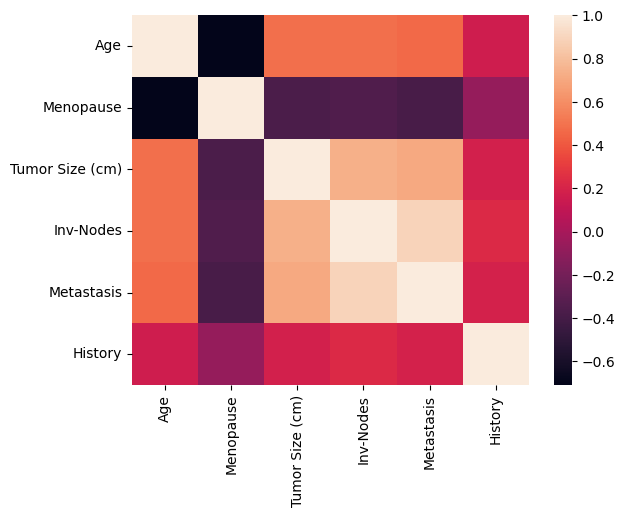

In [18]:
sns.heatmap(heat)

#### Split

In [19]:
X = df.drop('Diagnosis Result',axis=1)
y = df[['Diagnosis Result']]

#### Train, Test Split

In [20]:
#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Base Model

In [21]:
base_model = y_train.value_counts(normalize=True).max()
base_model

0.5647058823529412

#### Model Build: Transform, Scale, Fit-model

In [22]:
# Identify numeric & categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Full model
model = make_pipeline(preprocessor,  RandomForestClassifier(random_state=42))
model.fit(X_train, y_train)
model

C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Menopause',
                                                   'Tumor Size (cm)',
                                                   'Inv-Nodes', 'Metastasis',
                                                   'History']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Breast',
                                                   'Breast Quadrant'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

#### Evaluate

In [23]:
y_pred = model.predict(X_test)

#### Accuracy Score

In [24]:
accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8372


#### Classification Report

In [25]:
# Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Benign       0.84      0.88      0.86        24
   Malignant       0.83      0.79      0.81        19

    accuracy                           0.84        43
   macro avg       0.84      0.83      0.83        43
weighted avg       0.84      0.84      0.84        43



#### Confusion Matrix

In [26]:
print(confusion_matrix(y_test,y_pred))

[[21  3]
 [ 4 15]]


#### Visualize

<Figure size 500x500 with 0 Axes>

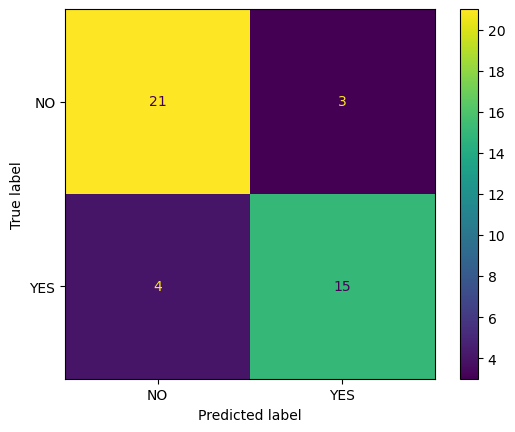

In [27]:
plt.figure(figsize=(5,5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NO", "YES"])
disp.plot()
plt.show()

#### Feature Importance Extraction

In [28]:
# numeric column names (unchanged)
feature_names_num = num_cols

# one-hot encoded column names
feature_names_cat = (
    model.named_steps['columntransformer']  # Preprocessor step
    .named_transformers_['cat']             # The categorical transformer
    .get_feature_names_out(cat_cols)
)

# all features together
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

# get the trained RandomForest model from the pipeline
rf_model = model.named_steps['randomforestclassifier']

# extract importances from the trained model
importances = rf_model.feature_importances_


#### Feature Importance Chart

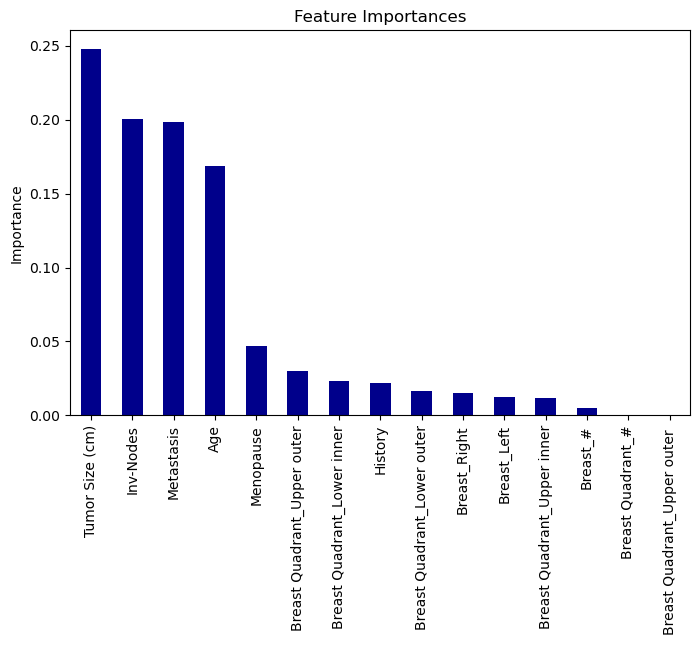

In [30]:
# Plot
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
plt.figure(figsize=(8,5))
feat_imp.plot(kind='bar', color='darkblue')
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.show()